# SECOM Data Modeling
---

### Imports and creating test-train split

In [73]:
# Imports
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
import warnings

In [ ]:
# silencing nuisance warnings
warnings.filterwarnings("ignore")

In [75]:
# Pulling in the SECOM data and loading data into feature and label dataframes
secom = fetch_ucirepo(id=179)
df = pd.DataFrame(secom.data.original)
X = df.drop(columns=["class", "timestamp"])
y = df["class"]
# converting "-1" passing label to "0"
y = y.replace(-1, 0)

In [76]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

class
0    0.933759
1    0.066241
Name: proportion, dtype: float64
class
0    0.933121
1    0.066879
Name: proportion, dtype: float64


___

### Creating custom Secom dataset preprocess transformer

In [78]:
class SecomPreProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, missing_threshold: int, corr_threshold: int):
        self.missing_threshold = missing_threshold
        self.corr_threshold = corr_threshold

    def fit(self, X: pd.DataFrame, y=None):
        X = X.copy()

        # filtering out features with null percentage above threshold
        self.null_cols_ = X.columns[X.isna().mean() > self.missing_threshold].to_list()
        X = X.drop(columns=self.null_cols_)
        
        # imputing NaN with median
        self.medians_ = X.median()
        X = X.fillna(self.medians_)

        # Remove constant variance features
        self.zero_var_cols_ = X.columns[X.var() == 0].to_list()
        X = X.drop(columns=self.zero_var_cols_)

        # dropping columns correlated above threshold
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

        self.corr_cols_ = [
            col
            for col in upper.columns
            if any(upper[col] > self.corr_threshold)
        ]

        X = X.drop(columns=self.corr_cols_)

        self.feature_names_out_ = X.columns.to_list()

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        X = X.drop(
            columns=self.null_cols_ + self.zero_var_cols_ + self.corr_cols_,
            errors="ignore"
        )

        X = X.fillna(self.medians_)

        if list(X.columns) != self.feature_names_out_:
            raise ValueError("Transformed columns do not match fitted columns.")

        return X

    def get_feature_names_out(self, input_features=None) -> np.array:
        return np.array(self.feature_names_out_)

___

### Custom PLSTransformer 
Needed since it returns X and y arrays, where models such as logistic regression expect only X.
This PLSTransformer is simply a custom transformer wrapper around PLSRegression to capture the X array of latent variables to be used in subsequent modeling.

In [ ]:
# Creating custom transformer to extract PLS components
class PLSTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=10):
        self.n_components = n_components

    def fit(self, X, y):
        self.pls_ = PLSRegression(n_components=self.n_components)
        self.pls_.fit(X, y)
        return self

    def transform(self, X):
        return self.pls_.transform(X)

___

### Creating a loop to test the performance of several models at once

In [80]:
# specifying dictionaries with two categories of models: ones that need scaling and those that do not (typically tree-based models)
models_needs_scaling = {
    "Logistic Regression": LogisticRegression(
        penalty='l1', 
        random_state=42, 
        class_weight="balanced", 
        solver='liblinear', 
        max_iter=5000        
    ),
    "SVM Linear": SVC(
        kernel="linear",
        C=1.0,
        class_weight="balanced",
        probability=True,
        random_state=42
    ),
    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    )
}
models_no_scaling = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (small)": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Histogram Gradient Boost": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric="logloss"
    )
}

In [81]:
# Adding this custom pipeline dictionary as the PLS modeling is a special case as it needs the special PLSTransformer we created
models_custom_pipelines = {
    f"PLS-DA {n} components": Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("scale", StandardScaler()),
        ("pls", PLSTransformer(n_components=n)),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])
    for n in [2, 5, 10, 15, 20, 30]
}

In [ ]:
# creating a function to run cross validation on multiple models at once and output their performance to a dataframe
def run_performance(models_needs_scaling: dict, models_no_scaling: dict, models_custom_pipelines: dict | None = None, 
                    X_train : pd.DataFrame = X_train, y_train: pd.DataFrame = y_train) -> pd.DataFrame:
    results = []

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def evaluate_pipe(name, pipe):
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "pr_auc": "average_precision"
            },
            return_train_score=True,
            n_jobs=-1
        )

        results.append({
            "model": name,
            "train_roc_auc": scores["train_roc_auc"].mean(),
            "train_pr_auc": scores["train_pr_auc"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_roc_auc_std": scores["test_roc_auc"].std(),
            "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
            "cv_pr_auc_std": scores["test_pr_auc"].std(),
        })


    for name, model in models_needs_scaling.items():
        pipe = Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("scale", StandardScaler()),
        ("model", model)
        ])

        evaluate_pipe(name, pipe)
        

    for name, model in models_no_scaling.items():
        pipe = Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("model", model)
        ])

        evaluate_pipe(name, pipe)

    if models_custom_pipelines is not None:
        for name, pipe in models_custom_pipelines.items():
            evaluate_pipe(name, pipe)

    performance_summary = pd.DataFrame(results).sort_values("cv_pr_auc_mean", ascending=False).reset_index(drop=True)
    return performance_summary

In [83]:
# Running performance checks
performance_summary = run_performance(models_needs_scaling=models_needs_scaling, models_no_scaling=models_no_scaling, 
                                      models_custom_pipelines=models_custom_pipelines)
performance_summary

,model,train_roc_auc,train_pr_auc,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,Random Forest (small),1.000000,1.000000,0.724020,0.048940,0.200041,0.052828
1,Random Forest,1.000000,1.000000,0.722766,0.054694,0.198035,0.059456
2,XGBoost,1.000000,1.000000,0.698303,0.063096,0.194247,0.048157
3,PLS-DA 2 components,0.901980,0.529548,0.662689,0.058279,0.161826,0.057569
4,PLS-DA 5 components,0.944674,0.702331,0.646732,0.037519,0.153672,0.052328
5,Logistic Regression,0.998701,0.970597,0.599604,0.082212,0.153012,0.079866
6,SVM Linear,0.999822,0.994890,0.577256,0.077944,0.148724,0.075724
7,SVM RBF,1.000000,1.000000,0.654456,0.083712,0.145575,0.051439
8,PLS-DA 20 components,0.980379,0.836153,0.646952,0.045097,0.143164,0.036943
9,Histogram Gradient Boost,1.000000,1.000000,0.655505,0.061309,0.142040,0.017916


In [ ]:
# Saving the table to markdown
# performance_summary.to_markdown(
#     "../tables/model_performance_summary.md",
#     index=False
# )

In [84]:
# Name of the best model
best_model_name = performance_summary["model"][0]

___

### Performing hyperparameter tuning on the best model

In [85]:
# Creating a pipe with the best model from the model selection step
rf_pipe = Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
        ))
])

In [86]:
# Creating the hyperparameter tuning dictionary with params and values to randomly search
param_dist = {
    "model__max_depth": [4, 6, 8, 10, 12, None],
    "model__min_samples_leaf": [2, 5, 10, 20, 30],
    "model__min_samples_split": [5, 10, 20, 40, 80],
    "model__max_features": ["sqrt", 0.10, 0.25, 0.50]
}

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [4, 6, ...], 'model__max_features': ['sqrt', 0.1, ...], 'model__min_samples_leaf': [2, 5, ...], 'model__min_samples_split': [5, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``

In [87]:
# Extracting the best pr-auc and hyperparameters from the random search
best_params_df = pd.DataFrame([search.best_params_])
best_params_df["cv_pr_auc"] = round(search.best_score_, 3)
best_params_df.insert(0, "best_model", best_model_name)

In [88]:
# Running predictions using the best pipeline on the holdout test set to determine performance
best_pipe = search.best_estimator_
y_proba = best_pipe.predict_proba(X_test)[:, 1]
best_params_df["test_pr_auc"] = round(average_precision_score(y_test, y_proba),3)
best_params_df["test_roc_auc"] = round(roc_auc_score(y_test, y_proba),3)
best_params_df

,best_model,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,cv_pr_auc,test_pr_auc,test_roc_auc
0,Random Forest (small),20,10,0.1,12,0.236,0.214,0.759


___

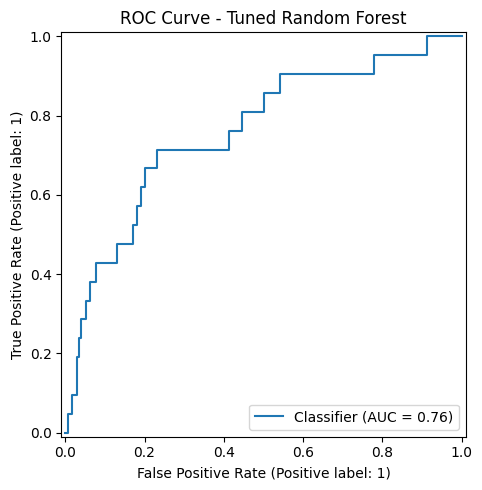

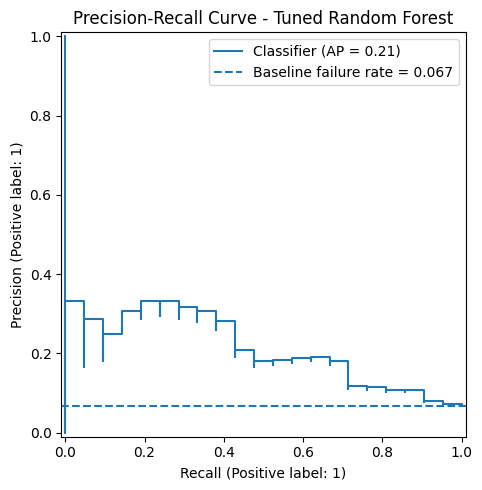

In [ ]:
# Plot ROC and Precision-Recall curves for tuned RF on holdout test set

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax
)

ax.set_title("ROC Curve - Tuned Random Forest")
plt.tight_layout()
# plt.savefig("../figures/tuned_rf_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax
)

ax.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline failure rate = {y_test.mean():.3f}"
)

ax.set_title("Precision-Recall Curve - Tuned Random Forest")
ax.legend()
plt.tight_layout()
# plt.savefig("../figures/tuned_rf_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### Fitting the best tuned model on all the training data and running a threshold sweep to identify the optimum cutoff for failed wafers

In [90]:
def threshold_sweep_from_proba(y_true, y_proba, thresholds):
    baseline_failure_rate = y_true.mean()
    results = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)

        results.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "flagged": y_pred.sum(),
            "flagged_rate": y_pred.mean(),
            "enrichment": precision / baseline_failure_rate
        })

    return (
        pd.DataFrame(results)
        .sort_values("threshold", ascending=False)
        .reset_index(drop=True)
    )

In [91]:
def eval_threshold(best_pipe: Pipeline, thresholds: list[int], X_train: pd.DataFrame = X_train, 
                   y_train: pd.DataFrame = y_train) -> pd.DataFrame:
    cv_proba = cross_val_predict(
        best_pipe,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    return threshold_sweep_from_proba(
        y_true=y_train,
        y_proba=cv_proba,
        thresholds=thresholds
    )

In [92]:
thresholds = np.arange(0.01, 0.51, 0.01)
cv_threshold_df = eval_threshold(best_pipe=best_pipe, thresholds=thresholds)
cv_threshold_df.round(3)

,threshold,precision,recall,f1,flagged,flagged_rate,enrichment
0,0.50,0.233,0.120,0.159,43,0.034,3.511
1,0.49,0.229,0.133,0.168,48,0.038,3.460
2,0.48,0.214,0.145,0.173,56,0.045,3.235
3,0.47,0.265,0.217,0.238,68,0.054,3.996
4,0.46,0.257,0.229,0.242,74,0.059,3.876
5,0.45,0.241,0.253,0.247,87,0.069,3.644
6,0.44,0.235,0.277,0.254,98,0.078,3.543
7,0.43,0.236,0.301,0.265,106,0.085,3.560
8,0.42,0.222,0.337,0.268,126,0.101,3.355
9,0.41,0.201,0.349,0.256,144,0.115,3.040


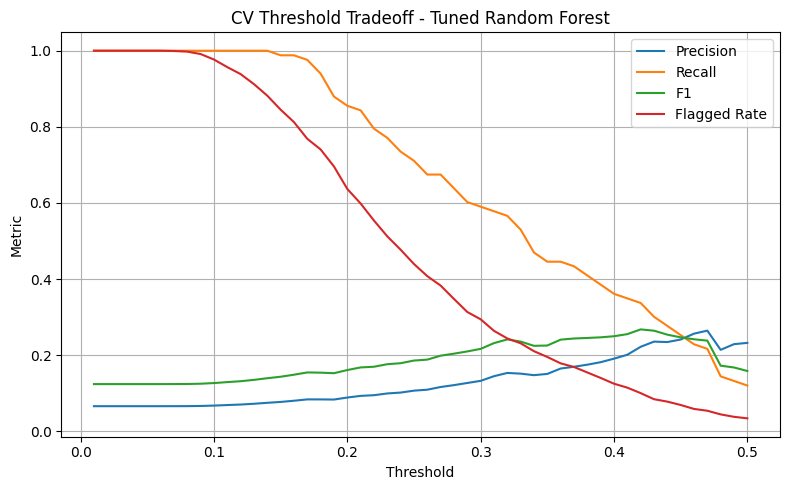

In [ ]:
# Plotting threshold analysis results
plt.figure(figsize=(8, 5))

plt.plot(cv_threshold_df["threshold"], cv_threshold_df["precision"], label="Precision")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["recall"], label="Recall")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["f1"], label="F1")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["flagged_rate"], label="Flagged Rate")

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("CV Threshold Tradeoff - Tuned Random Forest")
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig("../figures/cv_threshold_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

In [94]:
# Selected threshold for max performance: The final threshold was selected using the maximum F1 score from out-of-fold training predictions.
selected_threshold = cv_threshold_df.loc[cv_threshold_df["f1"].idxmax(), "threshold"]

In [95]:
# Final model performance evaluation
def eval_test_final(best_pipe: Pipeline, selected_threshold: int, X_train: pd.DataFrame = X_train, y_train: pd.DataFrame = y_train,
                    X_test: pd.DataFrame = X_test, y_test: pd.DataFrame = y_test):
    
    best_pipe.fit(X_train, y_train)
    test_proba = best_pipe.predict_proba(X_test)[:, 1]

    return threshold_sweep_from_proba(
        y_true=y_test,
        y_proba=test_proba,
        thresholds=[selected_threshold]
    )

In [96]:
# Run final model performance evaluation
eval_test_final_df = eval_test_final(best_pipe=best_pipe, selected_threshold=selected_threshold)
eval_test_final_df

,threshold,precision,recall,f1,flagged,flagged_rate,enrichment
0,0.42,0.285714,0.285714,0.285714,21,0.066879,4.272109


In [97]:
final_model_summary = pd.concat([best_params_df, eval_test_final_df], axis=1)
final_model_summary

,best_model,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,cv_pr_auc,test_pr_auc,test_roc_auc,threshold,precision,recall,f1,flagged,flagged_rate,enrichment
0,Random Forest (small),20,10,0.1,12,0.236,0.214,0.759,0.42,0.285714,0.285714,0.285714,21,0.066879,4.272109


___

### Assessing feature importance in the best model

In [98]:
# Cloning the best pipe for clarity
final_pipe = clone(best_pipe)
final_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,missing_threshold,0.9
,corr_threshold,0.95
Name,Type,Value
corr_cols_,list,"['At...28', 'At...37', 'At...97', 'At...05', ...]"
feature_names_out_,list,"['At... 1', 'At... 2', 'At... 3', 'At... 4', ...]"


In [99]:
feature_importances = final_pipe.named_steps["model"].feature_importances_
feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "sensor": feature_names,
    "feature_importance": feature_importances
    }).sort_values("feature_importance", ascending=False)

feature_importance_df.head(20)

,sensor,feature_importance
93,Attribute 104,0.047490
52,Attribute 60,0.042538
30,Attribute 34,0.029769
116,Attribute 131,0.021289
28,Attribute 32,0.020707
178,Attribute 214,0.019200
195,Attribute 248,0.017726
172,Attribute 206,0.016893
247,Attribute 511,0.013175
57,Attribute 65,0.012795


In [135]:
# Cross-validated permutation importance using training data only

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

perm_results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]

    fold_pipe = clone(best_pipe)
    fold_pipe.fit(X_fold_train, y_fold_train)

    perm = permutation_importance(
        fold_pipe,
        X_fold_val,
        y_fold_val,
        scoring="average_precision",
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    fold_perm_df = pd.DataFrame({
        "fold": fold,
        "feature": X_train.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })

    perm_results.append(fold_perm_df)

In [137]:
perm_df = (
    pd.concat(perm_results, ignore_index=True)
      .groupby("feature")
      .agg(
          importance_mean=("importance_mean", "mean"),
          importance_fold_std=("importance_mean", "std"),
          importance_repeat_std_mean=("importance_std", "mean")
      )
      .sort_values("importance_mean", ascending=False)
      .reset_index()
)

perm_df.head(20)

,feature,importance_mean,importance_fold_std,importance_repeat_std_mean
0,Attribute 104,0.018746,0.019179,0.022156
1,Attribute 201,0.010291,0.014426,0.005844
2,Attribute 588,0.010210,0.012501,0.006365
3,Attribute 65,0.009615,0.019942,0.006855
4,Attribute 34,0.009566,0.009601,0.014825
5,Attribute 32,0.009104,0.004664,0.013893
6,Attribute 60,0.008827,0.029010,0.019693
7,Attribute 66,0.008759,0.015116,0.005876
8,Attribute 132,0.007805,0.006038,0.006144
9,Attribute 206,0.007453,0.022974,0.015785


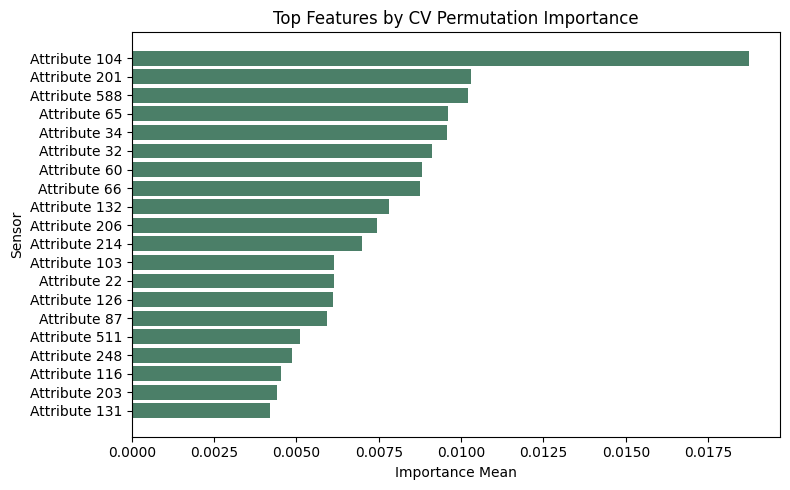

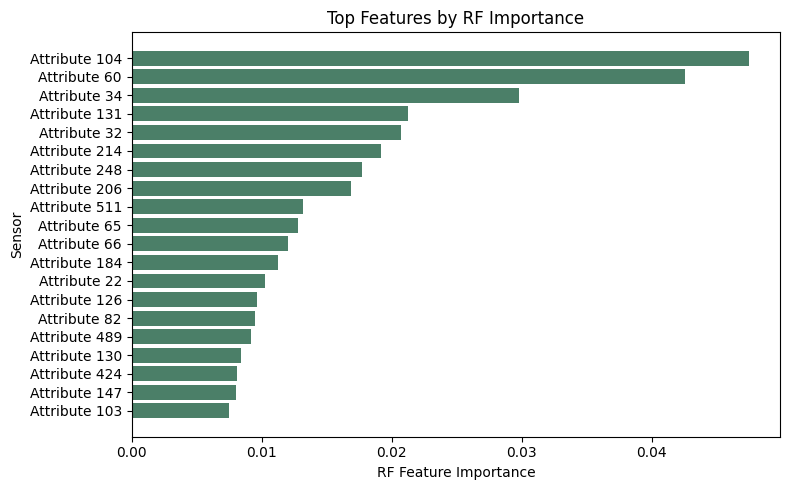

In [ ]:
top_features_perm = perm_df[:20].sort_values("importance_mean")
plt.subplots(figsize=(8,5))
plt.barh(top_features_perm["feature"], top_features_perm["importance_mean"], color="#4B7F68")
plt.xlabel("Importance Mean")
plt.ylabel("Sensor")
plt.title("Top Features by CV Permutation Importance")
plt.tight_layout()
# plt.savefig("../figures/permutation_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()


top_features_rf = feature_importance_df[:20].sort_values("feature_importance")
plt.subplots(figsize=(8,5))
plt.barh(top_features_rf["sensor"], top_features_rf["feature_importance"], color="#4B7F68")
plt.xlabel("RF Feature Importance")
plt.ylabel("Sensor")
plt.title("Top Features by RF Importance")
plt.tight_layout()
# plt.savefig("../figures/rf_feature_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()

In [191]:
# Evaluating feature importance using cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

top_features = []
all_fold_importances = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

    X_fold = X_train.iloc[train_idx]
    y_fold = y_train.iloc[train_idx]

    pipe = clone(best_pipe)
    pipe.fit(X_fold, y_fold)

    rf = pipe.named_steps["model"]

    feature_names = (
        pipe
        .named_steps["preprocess"]
        .get_feature_names_out()
    )

    fold_importance = pd.DataFrame({
        "fold": fold,
        "feature": feature_names,
        "importance": rf.feature_importances_
    })

    all_fold_importances.append(fold_importance)

    top100 = (
        fold_importance
        .sort_values("importance", ascending=False)
        .head(100)
    )

    top_features.extend(top100["feature"])

In [193]:
feature_stability_df = (
    pd.Series(top_features)
    .value_counts()
    .reset_index()
)

feature_stability_df.columns = ["feature", "top100_fold_count"]

feature_stability_df.head(30)

,feature,top100_fold_count
0,Attribute 34,5
1,Attribute 104,5
2,Attribute 60,5
3,Attribute 82,5
4,Attribute 206,5
5,Attribute 131,5
6,Attribute 511,5
7,Attribute 130,5
8,Attribute 32,5
9,Attribute 248,5


In [195]:
# Summarizing feature importance explorations
rf_top100 = set(feature_importance_df.head(100)["sensor"])

perm_top100 = set(perm_df.head(100)["feature"])

stable_features = set(
    feature_stability_df[
        feature_stability_df["top100_fold_count"] >= 4
    ]["feature"]
)

all_features = rf_top100 | perm_top100 | stable_features

consensus_df = pd.DataFrame({
    "feature": sorted(all_features)
})

consensus_df["rf_top100"] = consensus_df["feature"].isin(rf_top100)
consensus_df["perm_top100"] = consensus_df["feature"].isin(perm_top100)
consensus_df["stable"] = consensus_df["feature"].isin(stable_features)

consensus_df["score"] = (
    consensus_df["rf_top100"].astype(int)
    + consensus_df["perm_top100"].astype(int)
    + consensus_df["stable"].astype(int)
)

consensus_df = consensus_df.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

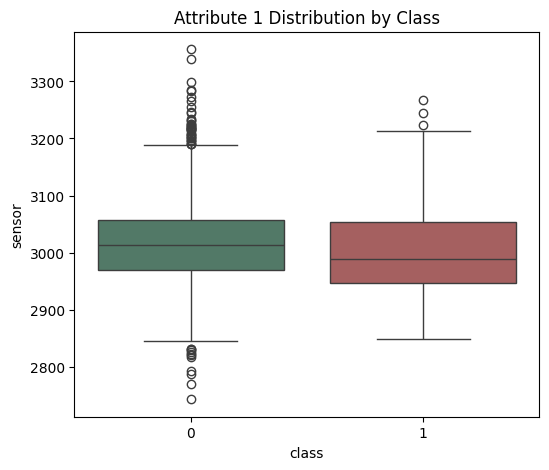

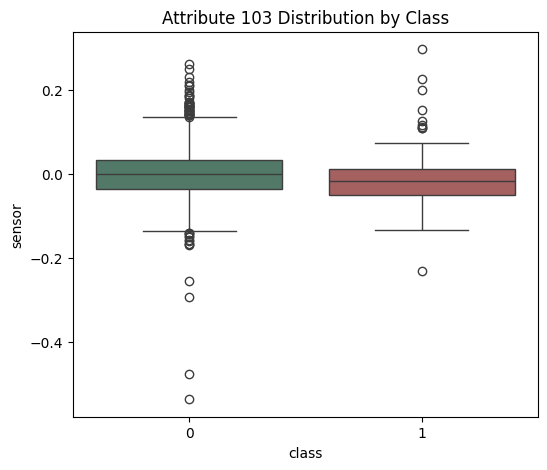

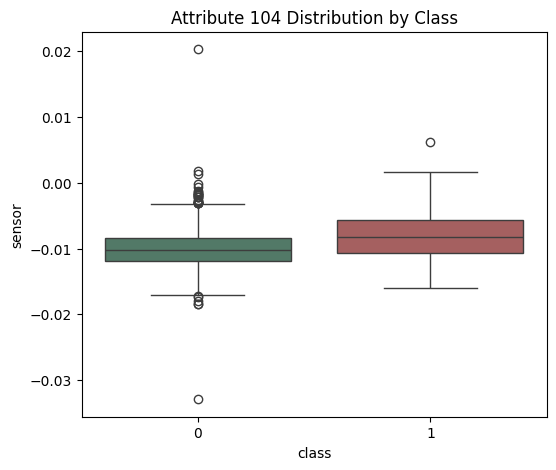

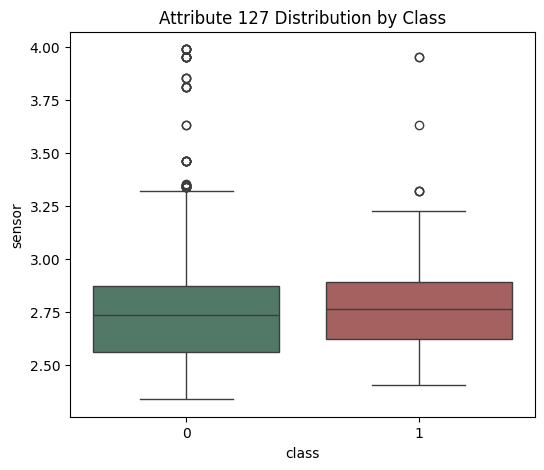

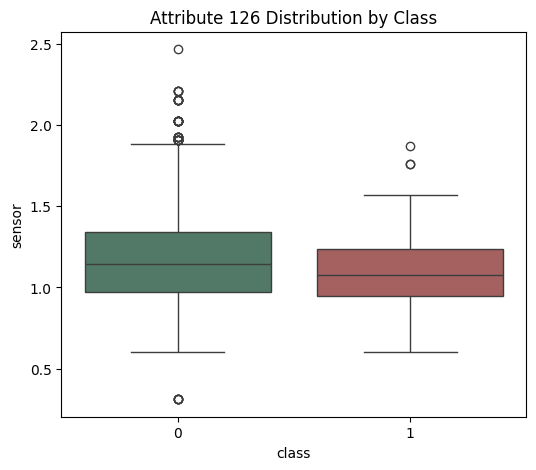

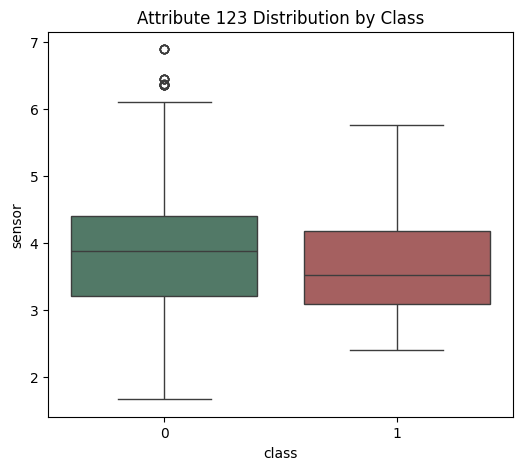

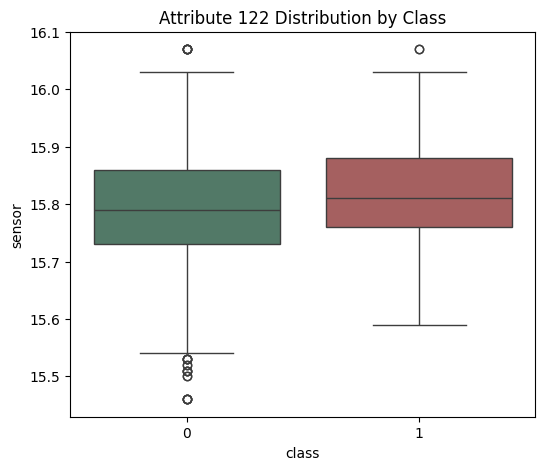

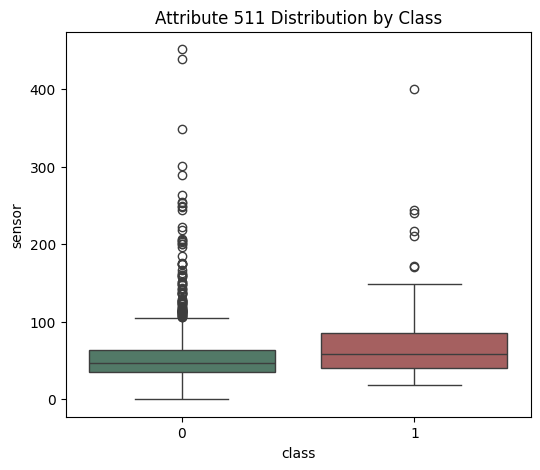

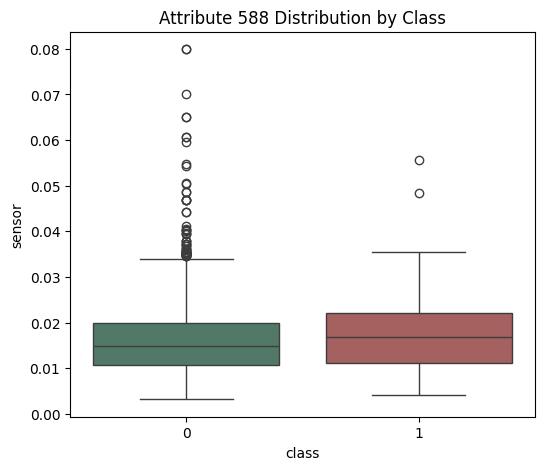

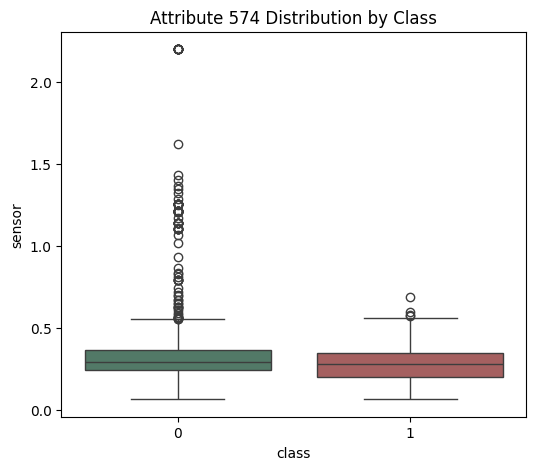

In [196]:
# Generating plots of the pass/fails by these top sensors

# Create boxplots of sensors
for sensor in consensus_df["feature"].head(10):

    plot_df = pd.DataFrame({
        "sensor": X[sensor],
        "class": y
    })

    plt.figure(figsize=(6,5))

    sns.boxplot(
        data=plot_df,
        x="class",
        y="sensor",
        hue="class",
        palette={
            0: "#4B7F68",   # Pass
            1: "#B15455"    # Fail
        },
        legend=False
    )

    plt.title(f"{sensor} Distribution by Class")
    plt.show()

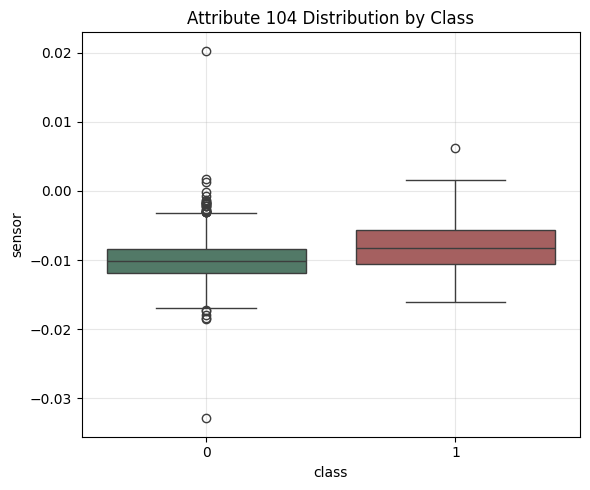

In [197]:
# Plotting Attibute 104 to save
att_104_df = pd.DataFrame({
    "sensor": X["Attribute 104"],
    "class": y
})

plt.figure(figsize=(6,5))

sns.boxplot(
    data=att_104_df,
    x="class",
    y="sensor",
    hue="class",
    palette={
        0: "#4B7F68",   # Pass
        1: "#B15455"    # Fail
    },
    legend=False
)

plt.title("Attribute 104 Distribution by Class")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("../figures/attribute_104_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

### Re-training the RF on only the top sensors to check performance

In [199]:
def run_reduced_model(pipe, consensus_df, X_train=X_train, y_train=y_train):
    results = []

    max_reduced_features = len(consensus_df)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for num_features in range(1, max_reduced_features + 1):
        key_features = consensus_df["feature"].head(num_features).to_list()
        X_train_red = X_train[key_features].copy()

        scores = cross_validate(
            clone(pipe),
            X_train_red,
            y_train,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "pr_auc": "average_precision"
            },
            return_train_score=True,
            n_jobs=-1
        )

        results.append({
            "model": f"RF (Top {num_features} Features)",
            "train_col_check": len(X_train_red.columns),
            "num_features": num_features,
            "train_roc_auc": scores["train_roc_auc"].mean(),
            "train_pr_auc": scores["train_pr_auc"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_roc_auc_std": scores["test_roc_auc"].std(),
            "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
            "cv_pr_auc_std": scores["test_pr_auc"].std(),
        })

    return pd.DataFrame(results).round(3)

In [200]:
# running the reduced model processing function
pipe_reduced = clone(best_pipe)
reduced_model_results = run_reduced_model(pipe=pipe_reduced, consensus_df=consensus_df)

In [ ]:
# displaying the results of the reduced model
reduced_model_results.sort_values("cv_pr_auc_mean", ascending=False).reset_index(drop=True).head(10)

,model,train_col_check,num_features,train_roc_auc,train_pr_auc,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,RF (Top 29 Features),29,29,1.0,0.998,0.798,0.029,0.315,0.040
1,RF (Top 48 Features),48,48,1.0,0.999,0.792,0.031,0.307,0.048
2,RF (Top 31 Features),31,31,1.0,0.999,0.787,0.021,0.306,0.049
3,RF (Top 44 Features),44,44,1.0,1.000,0.793,0.037,0.305,0.053
4,RF (Top 28 Features),28,28,1.0,0.998,0.790,0.027,0.304,0.034
5,RF (Top 63 Features),63,63,1.0,1.000,0.776,0.036,0.304,0.050
6,RF (Top 57 Features),57,57,1.0,1.000,0.773,0.033,0.304,0.050
7,RF (Top 56 Features),56,56,1.0,0.999,0.781,0.037,0.303,0.061
8,RF (Top 60 Features),60,60,1.0,1.000,0.771,0.031,0.302,0.048
9,RF (Top 32 Features),32,32,1.0,0.999,0.793,0.029,0.302,0.035


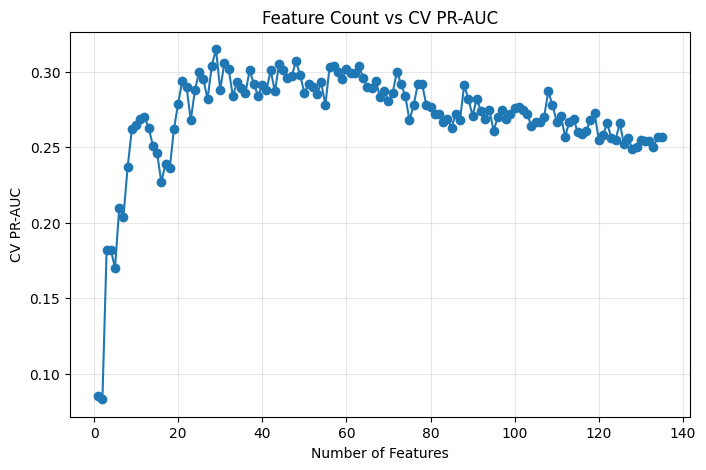

In [202]:
# plotting the cross-validated pr-auc as a function of the number of sensors included in the model
plt.figure(figsize=(8,5))

plt.plot(
    reduced_model_results["train_col_check"],
    reduced_model_results["cv_pr_auc_mean"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("CV PR-AUC")
plt.title("Feature Count vs CV PR-AUC")

plt.grid(alpha=0.3)

plt.show()

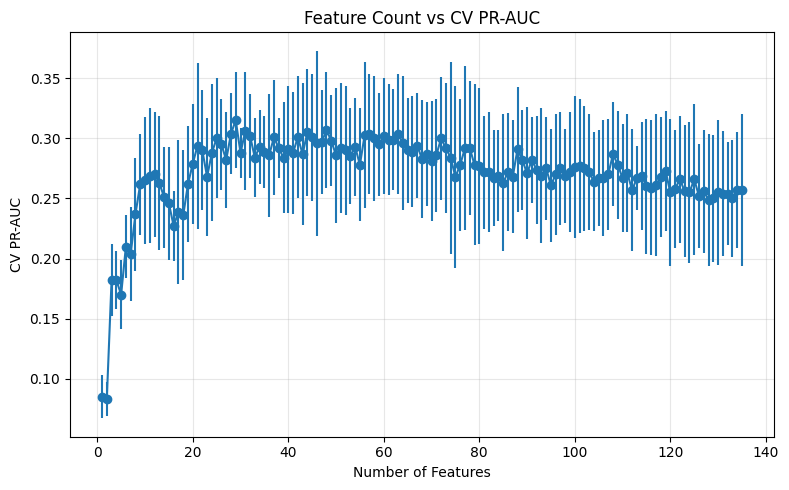

In [ ]:
# adding error bars to the above plot
plt.figure(figsize=(8,5))

plt.errorbar(
    reduced_model_results["train_col_check"],
    reduced_model_results["cv_pr_auc_mean"],
    yerr=reduced_model_results["cv_pr_auc_std"],
    fmt="o-"
)

plt.xlabel("Number of Features")
plt.ylabel("CV PR-AUC")
plt.title("Feature Count vs CV PR-AUC")

plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("../figures/reduced_feature_cv_pr_auc.png", dpi=300, bbox_inches="tight")
plt.show()

In [205]:
# since reduced model showed promise, creating a function to check different feature counts at various thresholds, then evaluating the best feature_counts
# at the best threshold on a hold out set once for final performance
def run_reduced_model_test(
    final_reduced_pipe,
    consensus_df,
    num_features,
    thresholds,
    cv,
    X_train= X_train,
    X_test = X_test,
    y_train= y_train,
    y_test = y_test
):

    key_features = consensus_df["feature"].head(num_features).to_list()

    X_train_red = X_train[key_features].copy()
    X_test_red = X_test[key_features].copy()

    y_train_red = y_train.copy()
    y_test_red = y_test.copy()

    # -----------------------------
    # 1. Choose threshold using OOF training predictions only
    # -----------------------------
    oof_proba = cross_val_predict(
        clone(final_reduced_pipe),
        X_train_red,
        y_train_red,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold_results = []

    baseline_train_failure_rate = y_train_red.mean()

    for threshold in thresholds:
        y_oof_pred = (oof_proba >= threshold).astype(int)

        threshold_results.append({
            "num_features": num_features,
            "threshold": threshold,
            "oof_pr_auc": average_precision_score(y_train_red, oof_proba),
            "oof_roc_auc": roc_auc_score(y_train_red, oof_proba),
            "oof_precision": precision_score(y_train_red, y_oof_pred, zero_division=0),
            "oof_recall": recall_score(y_train_red, y_oof_pred, zero_division=0),
            "oof_f1": f1_score(y_train_red, y_oof_pred, zero_division=0),
            "oof_flagged": y_oof_pred.sum(),
            "oof_flagged_rate": y_oof_pred.mean(),
            "oof_enrichment": precision_score(y_train_red, y_oof_pred, zero_division=0) / baseline_train_failure_rate
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_threshold = (
        threshold_df
        .sort_values("oof_f1", ascending=False)
        .iloc[0]["threshold"]
    )

    # -----------------------------
    # 2. Fit final model on full training set
    # -----------------------------
    final_model = clone(final_reduced_pipe)
    final_model.fit(X_train_red, y_train_red)

    # -----------------------------
    # 3. Evaluate once on holdout test set
    # -----------------------------
    test_proba = final_model.predict_proba(X_test_red)[:, 1]
    test_pred = (test_proba >= best_threshold).astype(int)

    baseline_test_failure_rate = y_test_red.mean()
    test_precision = precision_score(y_test_red, test_pred, zero_division=0)

    test_results = pd.DataFrame([{
        "model": f"RF (Top {num_features} Features)",
        "num_features": num_features,
        "selected_threshold": best_threshold,
        "test_pr_auc": average_precision_score(y_test_red, test_proba),
        "test_roc_auc": roc_auc_score(y_test_red, test_proba),
        "precision": test_precision,
        "recall": recall_score(y_test_red, test_pred, zero_division=0),
        "f1": f1_score(y_test_red, test_pred, zero_division=0),
        "flagged": test_pred.sum(),
        "flagged_rate": test_pred.mean(),
        "enrichment": test_precision / baseline_test_failure_rate
    }])

    return (
        test_results.round(3),
        threshold_df.sort_values("oof_f1", ascending=False).round(3),
        final_model,
        key_features
    )

In [222]:
# running the function from above with num_features of 29 (best performance on cv)
final_reduced_pipe = clone(best_pipe)
thresholds = np.arange(0.01, 1.00, 0.01)

reduced_model_test_perf, reduced_threshold_df, final_reduced_model, key_features = run_reduced_model_test(
    final_reduced_pipe=final_reduced_pipe,
    consensus_df=consensus_df,
    num_features=29,
    thresholds=thresholds,
    cv=cv
)

In [223]:
# Checking holdout performance for the 29-feature CV-selected model
reduced_model_test_perf

,model,num_features,selected_threshold,test_pr_auc,test_roc_auc,precision,recall,f1,flagged,flagged_rate,enrichment
0,RF (Top 29 Features),29,0.52,0.155,0.695,0.227,0.238,0.233,22,0.07,3.398


In [224]:
# checking the actual threshold level data for trends
reduced_threshold_df.head(10)

,num_features,threshold,oof_pr_auc,oof_roc_auc,oof_precision,oof_recall,oof_f1,oof_flagged,oof_flagged_rate,oof_enrichment
51,29,0.52,0.285,0.798,0.368,0.337,0.352,76,0.061,5.562
52,29,0.53,0.285,0.798,0.382,0.313,0.344,68,0.054,5.772
50,29,0.51,0.285,0.798,0.326,0.349,0.337,89,0.071,4.919
53,29,0.54,0.285,0.798,0.400,0.289,0.336,60,0.048,6.039
48,29,0.49,0.285,0.798,0.287,0.398,0.333,115,0.092,4.332
54,29,0.55,0.285,0.798,0.423,0.265,0.326,52,0.042,6.387
49,29,0.50,0.285,0.798,0.294,0.361,0.324,102,0.081,4.440
47,29,0.48,0.285,0.798,0.258,0.398,0.313,128,0.102,3.892
55,29,0.56,0.285,0.798,0.444,0.241,0.312,45,0.036,6.710
56,29,0.57,0.285,0.798,0.475,0.229,0.309,40,0.032,7.171


In [209]:
# sweeping the above threshold analysis across different top feature counts
feature_counts = [25, 30, 35, 40, 45, 49, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, len(consensus_df)]

all_holdout_results = []
all_threshold_results = {}

for n in feature_counts:
    test_result, threshold_df, final_model, key_features = run_reduced_model_test(
        final_reduced_pipe=clone(best_pipe),
        consensus_df=consensus_df,
        num_features=n,
        thresholds=np.arange(0.01, 1.00, 0.01),
        cv=cv
    )

    all_holdout_results.append(test_result)

    all_threshold_results[n] = {
        "threshold_df": threshold_df,
        "final_model": final_model,
        "key_features": key_features
    }

reduced_holdout_comparison = (
    pd.concat(all_holdout_results, ignore_index=True)
    .sort_values("test_pr_auc", ascending=False)
)

In [210]:
# checking best feature count / threshold combos
reduced_holdout_comparison

,model,num_features,selected_threshold,test_pr_auc,test_roc_auc,precision,recall,f1,flagged,flagged_rate,enrichment
8,RF (Top 65 Features),65,0.48,0.250,0.750,0.333,0.238,0.278,15,0.048,4.984
9,RF (Top 70 Features),70,0.49,0.249,0.763,0.333,0.238,0.278,15,0.048,4.984
10,RF (Top 75 Features),75,0.47,0.231,0.765,0.318,0.333,0.326,22,0.070,4.758
6,RF (Top 55 Features),55,0.44,0.226,0.762,0.226,0.333,0.269,31,0.099,3.376
13,RF (Top 90 Features),90,0.45,0.220,0.771,0.278,0.238,0.256,18,0.057,4.153
12,RF (Top 85 Features),85,0.45,0.218,0.765,0.300,0.286,0.293,20,0.064,4.486
11,RF (Top 80 Features),80,0.50,0.215,0.766,0.385,0.238,0.294,13,0.041,5.751
16,RF (Top 135 Features),135,0.49,0.214,0.768,0.333,0.190,0.242,12,0.038,4.984
5,RF (Top 49 Features),49,0.43,0.213,0.758,0.250,0.429,0.316,36,0.115,3.738
7,RF (Top 60 Features),60,0.48,0.209,0.752,0.278,0.238,0.256,18,0.057,4.153


In [ ]:
# saving reduced model results
# reduced_holdout_comparison.to_markdown(
#     "../tables/reduced_feature_results.md",
#     index=False
# )

In [ ]:
# Looking into the 65-feature threshold-level data
all_threshold_results[65]["threshold_df"].head(10)

,num_features,threshold,oof_pr_auc,oof_roc_auc,oof_precision,oof_recall,oof_f1,oof_flagged,oof_flagged_rate,oof_enrichment
47,65,0.48,0.268,0.78,0.278,0.361,0.314,108,0.086,4.193
48,65,0.49,0.268,0.78,0.292,0.337,0.313,96,0.077,4.403
45,65,0.46,0.268,0.78,0.256,0.386,0.308,125,0.100,3.865
46,65,0.47,0.268,0.78,0.258,0.373,0.305,120,0.096,3.900
44,65,0.45,0.268,0.78,0.239,0.410,0.302,142,0.113,3.615
42,65,0.43,0.268,0.78,0.221,0.434,0.293,163,0.130,3.334
43,65,0.44,0.268,0.78,0.225,0.410,0.291,151,0.121,3.399
41,65,0.42,0.268,0.78,0.211,0.458,0.289,180,0.144,3.187
49,65,0.50,0.268,0.78,0.286,0.289,0.287,84,0.067,4.313
54,65,0.55,0.268,0.78,0.380,0.229,0.286,50,0.040,5.737


___

### Project Summary

In [218]:
# Project summary table for the leakage-safe tuned Random Forest final model

final_full_pipe = clone(best_pipe)
final_full_pipe.fit(X_train, y_train)

test_proba_full = final_full_pipe.predict_proba(X_test)[:, 1]

# Recompute threshold using out-of-fold predictions from training data only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba_full = cross_val_predict(
    clone(best_pipe),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_df_full = threshold_sweep_from_proba(
    y_true=y_train,
    y_proba=oof_proba_full,
    thresholds=np.arange(0.01, 1.00, 0.01)
)

selected_threshold_full = threshold_df_full.loc[
    threshold_df_full["f1"].idxmax(),
    "threshold"
]

test_pred_full = (test_proba_full >= selected_threshold_full).astype(int)

baseline_test_failure_rate = y_test.mean()
test_precision_full = precision_score(y_test, test_pred_full, zero_division=0)

project_summary = pd.Series({
    "Samples": len(X),
    "Original Features": X.shape[1],
    "Features After Preprocessing": len(final_full_pipe.named_steps["preprocess"].get_feature_names_out()),
    "Baseline Failure Rate": f"{y.mean():.1%}",
    "Final Model": "Tuned Random Forest",
    "Holdout ROC-AUC": round(roc_auc_score(y_test, test_proba_full), 3),
    "Holdout PR-AUC": round(average_precision_score(y_test, test_proba_full), 3),
    "Selected Threshold": round(selected_threshold_full, 2),
    "Precision": round(test_precision_full, 3),
    "Recall": round(recall_score(y_test, test_pred_full, zero_division=0), 3),
    "F1": round(f1_score(y_test, test_pred_full, zero_division=0), 3),
    "Flagged Rate": f"{test_pred_full.mean():.1%}",
    "Enrichment": round(test_precision_full / baseline_test_failure_rate, 3)
}).to_frame("Value")

project_summary

,Value
Samples,1567
Original Features,590
Features After Preprocessing,280
Baseline Failure Rate,6.6%
Final Model,Tuned Random Forest
Holdout ROC-AUC,0.759
Holdout PR-AUC,0.214
Selected Threshold,0.42
Precision,0.286
Recall,0.286


In [ ]:
# Saving summary table to md
# project_summary.to_markdown(
#     "../tables/project_summary.md")

 ### Final Remarks

  This project evaluated the ability to predict manufacturing failures using the UCI SECOM semiconductor process dataset. The dataset
  contains 1,567 wafers, 590 process sensors, and a failure rate of approximately 6.6%.

  A leakage-safe preprocessing pipeline was developed to handle missing values, remove zero-variance sensors, and eliminate highly
  correlated features within each cross-validation fold. This was important because feature filtering on the full dataset would
  overstate out-of-sample performance.

  Several classification approaches were explored, including regularized logistic regression, support vector machines, PLS-DA, random
  forests, gradient boosting, and XGBoost. Tree-based ensemble models performed best under cross-validation, suggesting that the
  useful signal is nonlinear and not well captured by a simple linear decision boundary.

  The final model was a tuned Random Forest evaluated on a held-out test set after model selection and threshold selection were
  performed using training data only. The model achieved a holdout ROC-AUC of 0.759 and a holdout PR-AUC of 0.214. At the selected
  threshold, it flagged 6.7% of wafers and enriched the flagged group to about 4.3 times the baseline failure rate.

  Feature importance was evaluated using Random Forest impurity importance, cross-validated permutation importance, and cross-
  validation stability analysis. Attribute 104 was the strongest feature across both Random Forest importance and cross-validated
  permutation importance, making it the most consistent individual sensor signal in the modeling results. Other sensors, including
  Attributes 60, 34, 32, 65, 66, 206, 214, 248, and 511, also appeared repeatedly across importance methods.

  Reduced-feature modeling showed that feature reduction can improve cross-validated PR-AUC, but the optimal feature count was not
  stable on the holdout set. Training-only cross-validation favored a smaller reduced model, while an exploratory holdout sweep
  favored a broader feature set. Because the holdout set contains only a small number of failures, these differences should be treated
  cautiously rather than as proof of one exact optimal feature count.

  Overall, the project demonstrates that meaningful failure prediction is possible on the SECOM dataset, but the signal is subtle. The
  final model is best understood as a risk-ranking tool rather than a deterministic pass/fail classifier. The strongest conclusion is
  that a leakage-safe Random Forest can rank wafer risk above baseline and that the predictive signal is concentrated in a recurring
  subset of process sensors.